# TIGER Challenge — Detection Track: Data Preparation
## Macenko Stain Normalization + 512x512 Resize + COCO -> YOLOv8 Conversion

**Track:** Lymphocyte / plasma cell detection (bounding boxes)
**Input:** Streamed ROI images + COCO JSON from `s3://tiger-training/roi-level-annotations/`
**Output:** A YOLOv8-ready dataset (images/labels/data.yaml) saved to Google Drive

### Pipeline (per our EDA-informed decision)
1. Stream + re-index COCO annotations (same discovery logic as the EDA notebook)
2. **Macenko stain normalization** — added beyond the paper's baseline, justified by the
   clear R/G/B separation we found across TCGA/RUMC/JB sources in Step 7 of the Detection EDA
3. Resize every image to **512x512** (per the official baseline) and rescale bounding boxes to match
4. Convert COCO bounding boxes -> YOLOv8 label format (normalized `cx cy w h`)
5. Train / val / test split, **stratified by source** (RUMC/JB/TCGA) so each split has a
   representative mix rather than accidentally being dominated by one source
6. Save the final processed dataset to Google Drive (small — only the converted 512x512 set,
   not the raw multi-GB dataset) so it persists across Colab sessions
7. Visual QC: reload a few processed samples and confirm boxes still line up correctly

> **Note:** Run in Google Colab. We stream each raw image once, process it, and write out only
> the final processed version — we never bulk-download the raw dataset.


## Step 0 — Setup: install & import libraries

In [1]:
!pip install -q s3fs fsspec scikit-learn opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 58.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.


In [2]:
import os
import json
import re
import random
import shutil
from io import BytesIO
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

import s3fs

random.seed(42)
np.random.seed(42)


## Step 1 — Mount Google Drive (for the final processed dataset)

We only save the small, *processed* dataset here — not the raw multi-GB source data.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_ROOT = '/content/drive/MyDrive/tiger_dataset/detection_yolo'
os.makedirs(OUTPUT_ROOT, exist_ok=True)
print(f"Processed dataset will be saved to: {OUTPUT_ROOT}")


Mounted at /content/drive
Processed dataset will be saved to: /content/drive/MyDrive/tiger_dataset/detection_yolo


## Step 2 — Connect to S3 and re-index COCO annotations

Same discovery logic as the Detection EDA notebook: connect anonymously, glob for JSON/PNG,
filter for COCO-format files.


In [4]:
BUCKET_ROOT = "tiger-training/wsirois/roi-level-annotations"
s3 = s3fs.S3FileSystem(anon=True)

print("Discovering COCO JSON files...")
all_json = s3.glob(f"{BUCKET_ROOT}/**/*.json")
print("Discovering PNG image files...")
all_png = s3.glob(f"{BUCKET_ROOT}/**/*.png")

print(f"Found {len(all_json)} JSON files, {len(all_png)} PNG files")

png_by_name = defaultdict(list)
for p in all_png:
    png_by_name[os.path.basename(p)].append(p)


Discovering COCO JSON files...
Discovering PNG image files...
Found 1 JSON files, 4061 PNG files


In [5]:
def looks_like_coco(s3_path):
    try:
        with s3.open(s3_path, 'r') as f:
            data = json.load(f)
        return ('annotations' in data), data
    except Exception:
        return None, None

coco_files = []
for jp in tqdm(all_json, desc="Filtering COCO files"):
    is_coco, _ = looks_like_coco(jp)
    if is_coco:
        coco_files.append(jp)

print(f"COCO-format annotation files: {len(coco_files)}")


Filtering COCO files:   0%|          | 0/1 [00:00<?, ?it/s]

COCO-format annotation files: 1


## Step 3 — Build a unified category map

We read `categories` directly from the COCO files rather than assuming a fixed number of
classes — this keeps the conversion correct whether the dataset has one merged class or
separate lymphocyte/plasma-cell classes.


In [6]:
all_categories = {}
for jp in coco_files:
    with s3.open(jp, 'r') as f:
        data = json.load(f)
    for cat in data.get('categories', []):
        all_categories[cat['id']] = cat['name']

print("Categories found across all COCO files:")
for cid, name in sorted(all_categories.items()):
    print(f"  id={cid}: {name}")

# Build a contiguous 0-indexed mapping for YOLO (YOLO requires class ids starting at 0)
sorted_cat_ids = sorted(all_categories.keys())
cat_id_to_yolo_idx = {cid: idx for idx, cid in enumerate(sorted_cat_ids)}
yolo_class_names = [all_categories[cid] for cid in sorted_cat_ids]

print(f"\nYOLO class mapping: {cat_id_to_yolo_idx}")
print(f"YOLO class names (in order): {yolo_class_names}")


Categories found across all COCO files:
  id=1: lymphocytes and plasma cells

YOLO class mapping: {1: 0}
YOLO class names (in order): ['lymphocytes and plasma cells']


## Step 4 — Aggregate image + annotation records (same as EDA Step 5)

In [7]:
records = []
bbox_by_image = defaultdict(list)

for jp in tqdm(coco_files, desc="Aggregating COCO data"):
    with s3.open(jp, 'r') as f:
        data = json.load(f)

    images_by_id = {img['id']: img for img in data.get('images', [])}
    anns_by_image = defaultdict(list)
    for ann in data.get('annotations', []):
        anns_by_image[ann['image_id']].append(ann)

    for img_id, img_entry in images_by_id.items():
        fname = img_entry.get('file_name')
        width = img_entry.get('width')
        height = img_entry.get('height')

        candidates = png_by_name.get(os.path.basename(fname), [])
        if not candidates:
            continue  # skip images we can't locate (already flagged in EDA Step 4)

        records.append({
            'file_name': fname,
            's3_path': candidates[0],
            'width': width,
            'height': height,
            'n_cells': len(anns_by_image.get(img_id, [])),
        })

        for ann in anns_by_image.get(img_id, []):
            bbox_by_image[fname].append({
                'bbox': ann['bbox'],  # x, y, w, h in original pixel coords
                'category_id': ann.get('category_id'),
            })

df_images = pd.DataFrame(records)
print(f"Total usable ROI images: {len(df_images)}")


Aggregating COCO data:   0%|          | 0/1 [00:00<?, ?it/s]

Total usable ROI images: 1879


In [8]:
def infer_source(fname):
    basename = os.path.basename(fname)
    if re.match(r"TC_S\d+_P\d+", basename):
        return 'RUMC'
    if basename.startswith('TCGA'):
        return 'TCGA'
    if re.match(r"^\d+[BS]", basename):
        return 'JB'
    return 'unknown'

df_images['source'] = df_images['file_name'].apply(infer_source)
print(df_images['source'].value_counts())


source
TCGA    1744
RUMC      81
JB        54
Name: count, dtype: int64


## Step 5 — Macenko stain normalization

Self-contained implementation (no heavy external dependency like `spams`/`staintools`, which
can be finicky to install on Colab). We normalize every image to a **fixed reference stain
matrix** (standard values used across the stain-normalization literature) so the target
appearance doesn't depend on picking one image from our own dataset as a reference.


In [9]:
# Standard reference H&E stain vectors + max concentrations (widely used Macenko defaults)
HE_REFERENCE = np.array([[0.5626, 0.2159],
                          [0.7201, 0.8012],
                          [0.4062, 0.5581]])
MAX_C_REFERENCE = np.array([1.9705, 1.0308])


def macenko_normalize(img_rgb, Io=240, alpha=1, beta=0.15):
    """
    Macenko et al. (2009) stain normalization.
    img_rgb: HxWx3 uint8 RGB image.
    Returns normalized HxWx3 uint8 RGB image, or the original image if normalization
    isn't possible (e.g. near-blank / all-background patch).
    """
    h, w, c = img_rgb.shape
    img_flat = img_rgb.reshape(-1, 3).astype(np.float64)

    # Optical density conversion
    OD = -np.log((img_flat.astype(np.float64) + 1) / Io)

    # Remove pixels with OD below beta (background / near-white pixels)
    OD_thresh = OD[np.all(OD > beta, axis=1)]
    if OD_thresh.shape[0] < 10:
        # Not enough tissue signal to estimate stain vectors reliably
        return img_rgb

    # Eigen-decomposition of covariance matrix
    try:
        eigvals, eigvecs = np.linalg.eigh(np.cov(OD_thresh.T))
    except np.linalg.LinAlgError:
        return img_rgb

    # Project onto the plane spanned by the two largest eigenvectors
    top_eigvecs = eigvecs[:, [1, 2]]
    proj = OD_thresh.dot(top_eigvecs)

    # Find robust angle extremes
    phi = np.arctan2(proj[:, 1], proj[:, 0])
    min_phi = np.percentile(phi, alpha)
    max_phi = np.percentile(phi, 100 - alpha)

    v1 = top_eigvecs.dot(np.array([np.cos(min_phi), np.sin(min_phi)]))
    v2 = top_eigvecs.dot(np.array([np.cos(max_phi), np.sin(max_phi)]))

    # Order so first vector corresponds to Hematoxylin (by convention, larger R component)
    if v1[0] > v2[0]:
        stain_matrix = np.array([v1, v2]).T
    else:
        stain_matrix = np.array([v2, v1]).T

    # Solve for concentrations: OD = stain_matrix @ C
    try:
        C = np.linalg.lstsq(stain_matrix, OD.T, rcond=None)[0]
    except np.linalg.LinAlgError:
        return img_rgb

    max_C = np.percentile(C, 99, axis=1)
    max_C[max_C == 0] = 1e-6  # avoid divide-by-zero on degenerate patches

    # Rescale concentrations to reference max, then reconstruct using reference stain matrix
    C_scaled = C * (MAX_C_REFERENCE / max_C)[:, None]
    OD_normalized = HE_REFERENCE.dot(C_scaled)
    img_normalized = Io * np.exp(-OD_normalized)
    img_normalized = np.clip(img_normalized, 0, 255).T.reshape(h, w, 3).astype(np.uint8)

    return img_normalized


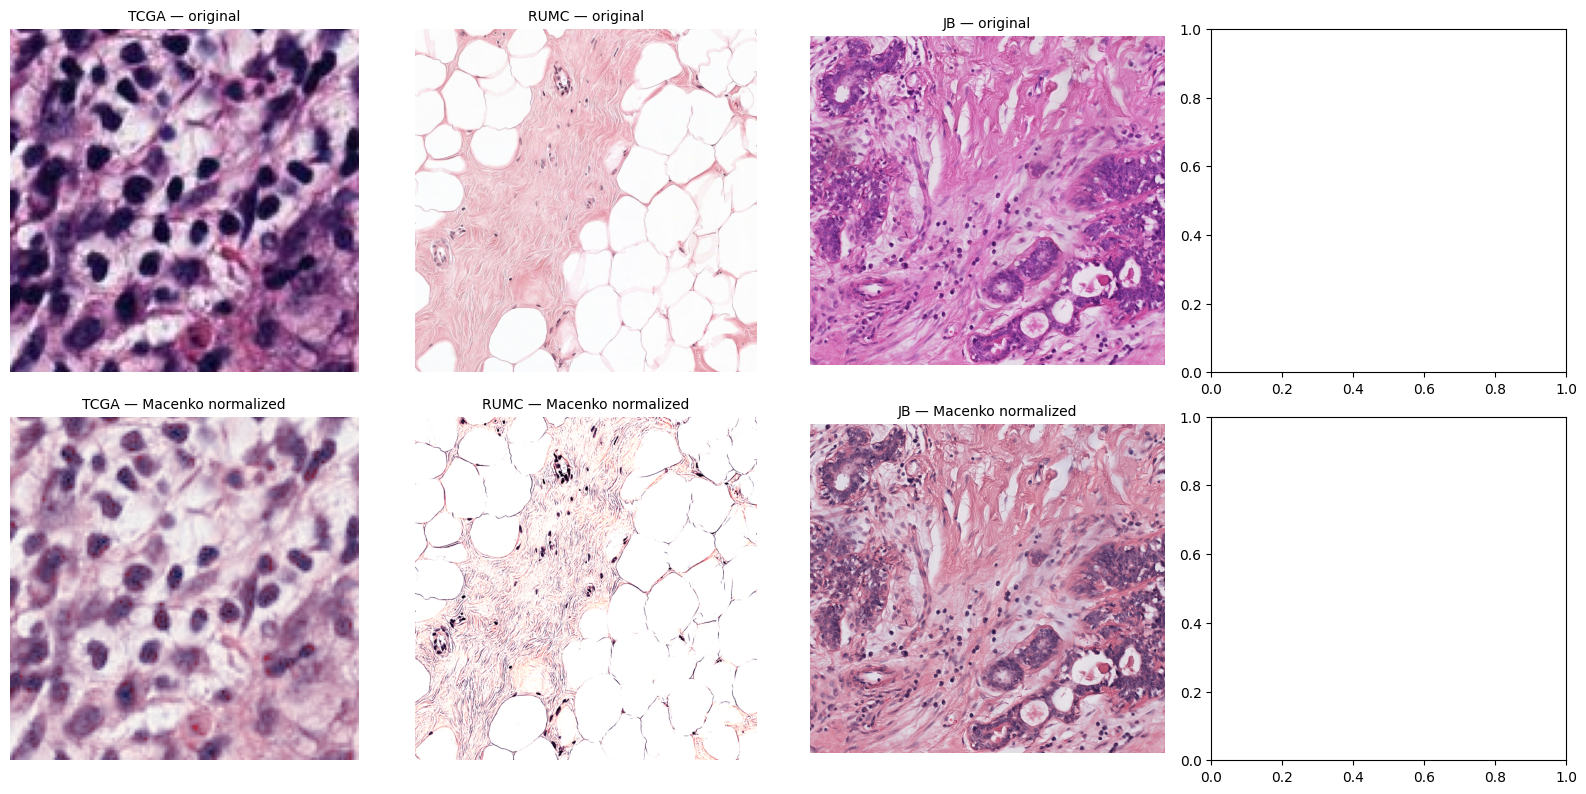

In [10]:
# Quick visual sanity check of the normalization on a few sample images from different sources
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, source in enumerate(df_images['source'].unique()[:4]):
    subset = df_images[df_images['source'] == source]
    if len(subset) == 0:
        continue
    row = subset.sample(1, random_state=1).iloc[0]

    with s3.open(row['s3_path'], 'rb') as f:
        img_bytes = f.read()
    im = np.asarray(Image.open(BytesIO(img_bytes)).convert('RGB'))

    normalized = macenko_normalize(im)

    axes[0, col].imshow(im)
    axes[0, col].set_title(f"{source} — original", fontsize=10)
    axes[0, col].axis('off')

    axes[1, col].imshow(normalized)
    axes[1, col].set_title(f"{source} — Macenko normalized", fontsize=10)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()


## Step 6 — Resize to 512x512 + rescale bounding boxes

Direct resize to a fixed 512x512 (matching the paper's baseline), scaling bounding box
coordinates independently in x and y to match.


In [11]:
TARGET_SIZE = 512

def resize_image_and_boxes(img_rgb, boxes_xywh, target_size=TARGET_SIZE):
    """
    img_rgb: HxWx3 uint8
    boxes_xywh: list of (x, y, w, h) in original pixel coords
    Returns resized image and rescaled boxes (still in absolute pixel coords, new size)
    """
    h, w = img_rgb.shape[:2]
    scale_x = target_size / w
    scale_y = target_size / h

    resized = cv2.resize(img_rgb, (target_size, target_size), interpolation=cv2.INTER_LINEAR)

    rescaled_boxes = []
    for (x, y, bw, bh) in boxes_xywh:
        rescaled_boxes.append((x * scale_x, y * scale_y, bw * scale_x, bh * scale_y))

    return resized, rescaled_boxes


def xywh_to_yolo(x, y, bw, bh, img_size=TARGET_SIZE):
    """Convert absolute (x, y, w, h) [top-left origin] to normalized YOLO (cx, cy, w, h)"""
    cx = (x + bw / 2) / img_size
    cy = (y + bh / 2) / img_size
    nw = bw / img_size
    nh = bh / img_size
    return cx, cy, nw, nh


## Step 7 — Train / val / test split (stratified by source)

70/15/15 split, stratified so each split preserves the RUMC/JB/TCGA proportions rather than
risking an accidental imbalance (e.g. test set ending up almost entirely TCGA).


In [12]:
train_df, temp_df = train_test_split(
    df_images, test_size=0.30, stratify=df_images['source'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['source'], random_state=42
)

print(f"Train: {len(train_df)}  ({train_df['source'].value_counts().to_dict()})")
print(f"Val:   {len(val_df)}  ({val_df['source'].value_counts().to_dict()})")
print(f"Test:  {len(test_df)}  ({test_df['source'].value_counts().to_dict()})")


Train: 1315  ({'TCGA': 1220, 'RUMC': 57, 'JB': 38})
Val:   282  ({'TCGA': 262, 'RUMC': 12, 'JB': 8})
Test:  282  ({'TCGA': 262, 'RUMC': 12, 'JB': 8})


## Step 8 — Process and write out the YOLO dataset

For each image: stream from S3 -> Macenko normalize -> resize to 512x512 + rescale boxes ->
write image + YOLO label file. Failures (e.g. normalization not possible on a near-blank
patch) fall back to the un-normalized resized image rather than being dropped, and are logged.


In [13]:
def setup_yolo_dirs(output_root):
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(output_root, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(output_root, 'labels', split), exist_ok=True)

setup_yolo_dirs(OUTPUT_ROOT)

processing_failures = []

def process_split(split_df, split_name):
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Processing {split_name}"):
        fname = row['file_name']
        s3_path = row['s3_path']
        out_stem = os.path.splitext(os.path.basename(fname))[0]

        try:
            with s3.open(s3_path, 'rb') as f:
                img_bytes = f.read()
            img = np.asarray(Image.open(BytesIO(img_bytes)).convert('RGB'))
        except Exception as e:
            processing_failures.append((fname, f"read failed: {str(e)[:60]}"))
            continue

        try:
            normalized = macenko_normalize(img)
        except Exception as e:
            processing_failures.append((fname, f"stain norm failed, used original: {str(e)[:60]}"))
            normalized = img

        boxes = [b['bbox'] for b in bbox_by_image.get(fname, [])]
        cat_ids = [b['category_id'] for b in bbox_by_image.get(fname, [])]

        resized_img, resized_boxes = resize_image_and_boxes(normalized, boxes)

        # Write image
        out_img_path = os.path.join(OUTPUT_ROOT, 'images', split_name, out_stem + '.png')
        Image.fromarray(resized_img).save(out_img_path)

        # Write YOLO label file (one line per box; empty file if no annotations)
        out_label_path = os.path.join(OUTPUT_ROOT, 'labels', split_name, out_stem + '.txt')
        with open(out_label_path, 'w') as f:
            for (x, y, bw, bh), cid in zip(resized_boxes, cat_ids):
                cx, cy, nw, nh = xywh_to_yolo(x, y, bw, bh)
                yolo_idx = cat_id_to_yolo_idx.get(cid, 0)
                f.write(f"{yolo_idx} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n")

process_split(train_df, 'train')
process_split(val_df, 'val')
process_split(test_df, 'test')

print(f"\n✓ Done. Processing failures (fell back to original image): {len(processing_failures)}")
for f in processing_failures[:10]:
    print(f"  {f}")


Processing train:   0%|          | 0/1315 [00:00<?, ?it/s]

Processing val:   0%|          | 0/282 [00:00<?, ?it/s]

Processing test:   0%|          | 0/282 [00:00<?, ?it/s]


✓ Done. Processing failures (fell back to original image): 0


## Step 9 — Write `data.yaml` for Ultralytics YOLOv8

In [14]:
data_yaml_content = f"""path: {OUTPUT_ROOT}
train: images/train
val: images/val
test: images/test

nc: {len(yolo_class_names)}
names: {yolo_class_names}
"""

data_yaml_path = os.path.join(OUTPUT_ROOT, 'data.yaml')
with open(data_yaml_path, 'w') as f:
    f.write(data_yaml_content)

print(f"data.yaml written to {data_yaml_path}:\n")
print(data_yaml_content)


data.yaml written to /content/drive/MyDrive/tiger_dataset/detection_yolo/data.yaml:

path: /content/drive/MyDrive/tiger_dataset/detection_yolo
train: images/train
val: images/val
test: images/test

nc: 1
names: ['lymphocytes and plasma cells']



## Step 10 — Visual QC: reload processed samples and confirm boxes line up

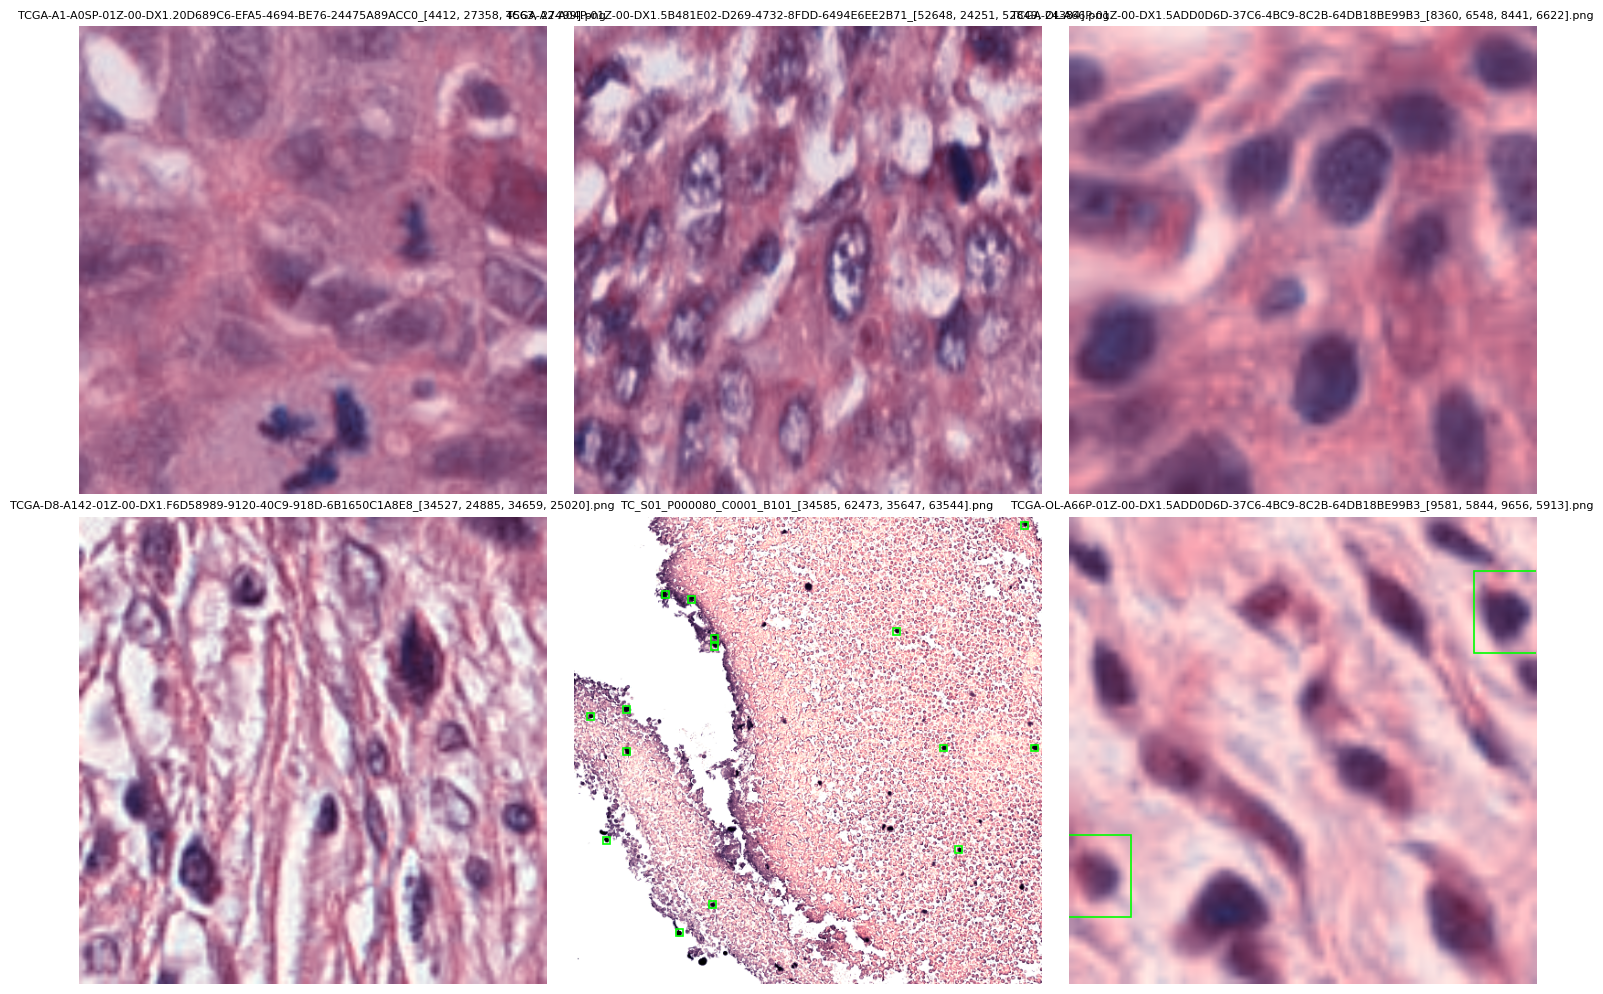

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

qc_files = os.listdir(os.path.join(OUTPUT_ROOT, 'images', 'train'))
qc_sample = random.sample(qc_files, min(6, len(qc_files)))

for ax, fname in zip(axes, qc_sample):
    img_path = os.path.join(OUTPUT_ROOT, 'images', 'train', fname)
    label_path = os.path.join(OUTPUT_ROOT, 'labels', 'train', os.path.splitext(fname)[0] + '.txt')

    im = Image.open(img_path)
    ax.imshow(im)
    ax.set_title(fname, fontsize=8)
    ax.axis('off')

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            _, cx, cy, nw, nh = map(float, parts)
            x = (cx - nw / 2) * TARGET_SIZE
            y = (cy - nh / 2) * TARGET_SIZE
            w = nw * TARGET_SIZE
            h = nh * TARGET_SIZE
            rect = patches.Rectangle((x, y), w, h, linewidth=1.2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)

plt.tight_layout()
plt.show()


## Summary

- **Stain normalization:** Macenko, applied to every image (with graceful fallback to
  un-normalized on near-blank patches — see failure log in Step 8)
- **Resize:** all images -> 512x512, boxes rescaled to match
- **Format:** YOLOv8-ready (`images/`, `labels/`, `data.yaml`) at `{OUTPUT_ROOT}`
- **Split:** 70/15/15 train/val/test, stratified by source (RUMC/JB/TCGA)

**Next steps:**
1. (Optional) Upload this processed dataset to Roboflow for versioning/augmentation
2. Build the **YOLOv8 training notebook** — load `data.yaml`, train, validate (F1, mAP@0.5, mAP@0.75)
3. In parallel, build the **Segmentation data-preparation notebook** (256x256 patches, ImageNet norm, stain norm, 7->3 class remap — already scoped in the Segmentation EDA)


# TIGER Challenge — Detection Track: Model Training
## Configurable Architecture (YOLOv8 / Faster R-CNN / RetinaNet) + Mask-Guided Patch Selection

**Track:** Lymphocyte / plasma cell detection (bounding boxes)
**Input:** The YOLO-format dataset produced by `03_DataPrep_Detection.ipynb`
(`images/{train,val,test}`, `labels/{train,val,test}`, `data.yaml`)

### What this notebook does
1. **Explains every input you need to set** in one config cell — no hunting through the notebook
2. Loads the dataset and confirms the counts match what you expect (you mentioned **4016 PNG
   images** total — we sanity-check against that)
3. **Optional: mask-guided patch selection**, mirroring the official TIGER pipeline's
   "Top-K high peritumoral stroma area patches" step — ranks training images by stroma
   content (using ground-truth tissue masks from the Segmentation data-prep notebook) and
   restricts training to the top fraction
4. **Augmentation**: YOLOv8's built-in augmentation (mosaic, flips, HSV jitter, etc.),
   exposed as an editable config so you can turn things on/off
5. **Three swappable architectures**, selected by one config variable:
   - `yolov8` (n/s/m/l/x — via Ultralytics)
   - `faster_rcnn` (torchvision, ResNet50-FPN backbone)
   - `retinanet` (torchvision, ResNet50-FPN backbone)
6. Validation metrics for whichever architecture you ran: **F1, mAP@0.5, mAP@0.5:0.95**
7. A **model comparison table** you build up across runs (log each run's metrics to a shared
   CSV in Drive, then compare)

> **Note:** Every piece of custom logic in this notebook (the YOLO-format Dataset class for
> torchvision models, the collate function, both training loops, and the mask-guided ranking
> function) was tested end-to-end on synthetic data — including the zero-annotation edge case
> — before being placed here. The one thing that **hasn't** been tested against is your actual
> S3-streamed dataset, since that's not reachable from where I built this.


In [16]:
!pip install -q ultralytics torchmetrics pycocotools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 53.7 MB/s eta 0:00:00


In [17]:
import os
import json
import shutil
import random
from io import BytesIO
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn, retinanet_resnet50_fpn
)
from torchmetrics.detection.mean_ap import MeanAveragePrecision

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if DEVICE.type == 'cpu':
    print("WARNING: No GPU detected. In Colab, go to Runtime > Change runtime type > GPU.")


Using device: cuda


## Step 1 — CONFIG: everything you need to set is here

This is the **only cell you need to edit** to change architecture, model size, training
length, or toggle mask-guided selection. Everything below reads from this config.

| Setting | What it controls |
|---|---|
| `DATASET_ROOT` | Path to the output of `03_DataPrep_Detection.ipynb` (your Drive path) |
| `ARCHITECTURE` | `'yolov8'`, `'faster_rcnn'`, or `'retinanet'` |
| `YOLO_MODEL_SIZE` | Only used if `ARCHITECTURE='yolov8'`: `'n'`, `'s'`, `'m'`, `'l'`, `'x'` (nano -> extra-large; bigger = more accurate but slower) |
| `EPOCHS`, `BATCH_SIZE`, `IMG_SIZE` | Standard training hyperparameters |
| `USE_AUGMENTATION` | Toggle YOLOv8's built-in augmentation on/off (only affects `yolov8`; the torchvision models here train without augmentation by default — see Step 5 note) |
| `USE_MASK_GUIDED_SELECTION` | If `True`, restrict training images to the top `TOP_K_FRACTION` by peritumoral stroma content (requires `SEGMENTATION_MASKS_ROOT`) |
| `TOP_K_FRACTION` | e.g. `0.5` = train on the 50% of images with the most stroma |


In [30]:
# ============================================================
# CONFIG — edit this cell
# ============================================================

# --- Paths ---
DATASET_ROOT = '/content/drive/MyDrive/tiger_dataset/detection_yolo'  # from notebook 03
RUNS_ROOT = '/content/drive/MyDrive/tiger_dataset/detection_runs'      # where results/checkpoints go

# --- Architecture selection ---
ARCHITECTURE = 'faster_rcnn'          # 'yolov8' | 'faster_rcnn' | 'retinanet'
YOLO_MODEL_SIZE = 'n'            # 'n' | 's' | 'm' | 'l' | 'x'  (only used if ARCHITECTURE == 'yolov8')

# --- Training hyperparameters ---
EPOCHS = 50
BATCH_SIZE = 16
IMG_SIZE = 512                   # matches the 512x512 resize from data prep
LEARNING_RATE = 0.005            # only used by the torchvision (faster_rcnn/retinanet) training loop

# --- Augmentation (YOLOv8 built-in; see Step 5 for details on each) ---
USE_AUGMENTATION = True
AUG_CONFIG = {
    'mosaic': 1.0,       # probability of mosaic augmentation (combines 4 images)
    'fliplr': 0.5,       # horizontal flip probability
    'flipud': 0.2,       # vertical flip probability (histopathology has no fixed 'up', so this is safe to use, unlike natural images)
    'hsv_h': 0.015,       # hue jitter
    'hsv_s': 0.5,         # saturation jitter — kept modest since we already stain-normalized
    'hsv_v': 0.3,         # brightness jitter
    'degrees': 15.0,      # rotation range (histopathology has no canonical orientation, so rotation is safe/useful)
    'translate': 0.1,     # translation
    'scale': 0.3,         # scale jitter
    'shear': 0.0,
    'perspective': 0.0,
}

# --- Mask-guided patch selection (optional, per the official pipeline's patch-selection step) ---
USE_MASK_GUIDED_SELECTION = False   # set True to enable
SEGMENTATION_MASKS_ROOT = '/content/drive/MyDrive/tiger_dataset/segmentation_patches'  # from notebook 04
TOP_K_FRACTION = 0.5                # train on top 50% of images by stroma content, if enabled

os.makedirs(RUNS_ROOT, exist_ok=True)
print("Config set:")
print(f"  Architecture: {ARCHITECTURE}" + (f" (yolov8{YOLO_MODEL_SIZE})" if ARCHITECTURE == 'yolov8' else ""))
print(f"  Epochs: {EPOCHS}, Batch size: {BATCH_SIZE}, Image size: {IMG_SIZE}")
print(f"  Mask-guided selection: {USE_MASK_GUIDED_SELECTION}")


Config set:
  Architecture: faster_rcnn
  Epochs: 50, Batch size: 16, Image size: 512
  Mask-guided selection: False


In [31]:
def count_split(split):
    img_dir = os.path.join(DATASET_ROOT, 'images', split)
    if not os.path.exists(img_dir):
        return 0
    return len([f for f in os.listdir(img_dir) if f.lower().endswith('.png')])

train_count = count_split('train')
val_count = count_split('val')
test_count = count_split('test')
total_count = train_count + val_count + test_count

print(f"Train: {train_count}")
print(f"Val:   {val_count}")
print(f"Test:  {test_count}")
print(f"Total: {total_count}")

if total_count == 0:
    raise FileNotFoundError(
        f"No images found under {DATASET_ROOT}. "
        f"Check that notebook 03_DataPrep_Detection.ipynb has been run and DATASET_ROOT is correct."
    )

expected_total = 4016
if total_count != expected_total:
    print(f"\nNote: found {total_count} images, you mentioned {expected_total}. "
          f"This might be expected (e.g. if some images were skipped for missing files during "
          f"data prep) — worth a quick check if the difference is large.")
else:
    print(f"\n✓ Matches expected total of {expected_total} images.")


Train: 1315
Val:   282
Test:  282
Total: 1879

Note: found 1879 images, you mentioned 4016. This might be expected (e.g. if some images were skipped for missing files during data prep) — worth a quick check if the difference is large.


In [32]:
# Load data.yaml to confirm class names
import yaml

with open(os.path.join(DATASET_ROOT, 'data.yaml'), 'r') as f:
    data_yaml = yaml.safe_load(f)

print("data.yaml contents:")
print(data_yaml)

NUM_CLASSES = data_yaml['nc']
CLASS_NAMES = data_yaml['names']


data.yaml contents:
{'path': '/content/drive/MyDrive/tiger_dataset/detection_yolo', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'nc': 1, 'names': ['lymphocytes and plasma cells']}


## Step 3 — (Optional) Mask-guided patch selection

Mirrors the official TIGER pipeline's patch-selection step, which ranks candidate patches by
**peritumoral stroma area** and keeps only the top-K before running detection. We use the
**ground-truth tissue masks** from the Segmentation data-prep notebook to compute stroma
fraction per training image now (rather than waiting for a trained segmentation model) —
once you have a trained UNet, you can swap in its predicted masks here instead by changing
`load_mask_for_stem` to run inference rather than read the ground-truth file.

This cell only runs if `USE_MASK_GUIDED_SELECTION = True` in the config above.


In [33]:
def find_matching_mask(stem, masks_root):
    """
    Look for a ground-truth mask matching this detection-image stem in the segmentation
    patch dataset. Since the segmentation patches were tiled (256x256) from the same ROIs,
    we match by stem PREFIX (the original ROI name, before the '_pNNN' patch suffix) and
    aggregate stroma fraction across all patches belonging to that ROI.
    """
    matches = []
    for split in ['train', 'val', 'test']:
        mask_dir = os.path.join(masks_root, 'masks', split)
        if not os.path.exists(mask_dir):
            continue
        for fname in os.listdir(mask_dir):
            if fname.startswith(stem + '_p'):
                matches.append(os.path.join(mask_dir, fname))
    return matches


def compute_stroma_fraction(stem, masks_root):
    """Fraction of pixels labeled Stroma (class 2) across all mask patches for this ROI."""
    mask_paths = find_matching_mask(stem, masks_root)
    if not mask_paths:
        return None  # no matching segmentation mask found for this image
    total_pixels = 0
    stroma_pixels = 0
    for mp in mask_paths:
        arr = np.asarray(Image.open(mp))
        total_pixels += arr.size
        stroma_pixels += int((arr == 2).sum())
    return stroma_pixels / total_pixels if total_pixels > 0 else 0.0


selected_stems = None  # None means "use all images" (default / mask-guided selection off)

if USE_MASK_GUIDED_SELECTION:
    train_files = [f for f in os.listdir(os.path.join(DATASET_ROOT, 'images', 'train'))
                   if f.lower().endswith('.png')]
    train_stems = [os.path.splitext(f)[0] for f in train_files]

    stroma_fractions = {}
    no_mask_found = []
    for stem in tqdm(train_stems, desc="Computing stroma fractions"):
        frac = compute_stroma_fraction(stem, SEGMENTATION_MASKS_ROOT)
        if frac is None:
            no_mask_found.append(stem)
        else:
            stroma_fractions[stem] = frac

    print(f"Images with a matching segmentation mask: {len(stroma_fractions)} / {len(train_stems)}")
    print(f"Images with NO matching mask (will be excluded from ranking, kept by default): {len(no_mask_found)}")

    n_select = max(1, int(len(stroma_fractions) * TOP_K_FRACTION))
    ranked = sorted(stroma_fractions.items(), key=lambda x: x[1], reverse=True)
    top_stems = set(stem for stem, _ in ranked[:n_select])

    # Images with no matching mask are kept by default (we don't have information to exclude them)
    selected_stems = top_stems | set(no_mask_found)

    print(f"\nSelected {len(selected_stems)} / {len(train_stems)} training images "
          f"(top {TOP_K_FRACTION*100:.0f}% by stroma content + unmatched images kept by default)")

    plt.figure(figsize=(8, 4))
    plt.hist(list(stroma_fractions.values()), bins=30, color='seagreen', edgecolor='black')
    plt.axvline(sorted(stroma_fractions.values())[-n_select] if n_select <= len(stroma_fractions) else 0,
                color='red', linestyle='--', label=f'top {TOP_K_FRACTION*100:.0f}% cutoff')
    plt.title('Stroma fraction distribution across training images')
    plt.xlabel('Stroma fraction')
    plt.ylabel('Count')
    plt.legend()
    plt.show()
else:
    print("Mask-guided selection is OFF. Training on all images. "
          "Set USE_MASK_GUIDED_SELECTION=True in the config cell to enable it.")


Mask-guided selection is OFF. Training on all images. Set USE_MASK_GUIDED_SELECTION=True in the config cell to enable it.


## Step 4 — If mask-guided selection is on: build a filtered training folder

YOLOv8 and the torchvision training loop both expect a folder of files, so if selection is
enabled we symlink only the selected images/labels into a filtered folder rather than copying
(keeps this fast and avoids duplicating data on Drive).


In [34]:
if USE_MASK_GUIDED_SELECTION and selected_stems is not None:
    FILTERED_ROOT = os.path.join(RUNS_ROOT, 'filtered_train')
    for sub in ['images', 'labels']:
        os.makedirs(os.path.join(FILTERED_ROOT, sub), exist_ok=True)

    for stem in tqdm(selected_stems, desc="Building filtered training set"):
        src_img = os.path.join(DATASET_ROOT, 'images', 'train', stem + '.png')
        src_label = os.path.join(DATASET_ROOT, 'labels', 'train', stem + '.txt')
        dst_img = os.path.join(FILTERED_ROOT, 'images', stem + '.png')
        dst_label = os.path.join(FILTERED_ROOT, 'labels', stem + '.txt')

        if not os.path.exists(dst_img) and os.path.exists(src_img):
            os.symlink(src_img, dst_img)
        if not os.path.exists(dst_label) and os.path.exists(src_label):
            os.symlink(src_label, dst_label)

    TRAIN_IMAGES_DIR = os.path.join(FILTERED_ROOT, 'images')
    TRAIN_LABELS_DIR = os.path.join(FILTERED_ROOT, 'labels')
    print(f"Filtered training set built at {FILTERED_ROOT} ({len(selected_stems)} images)")
else:
    TRAIN_IMAGES_DIR = os.path.join(DATASET_ROOT, 'images', 'train')
    TRAIN_LABELS_DIR = os.path.join(DATASET_ROOT, 'labels', 'train')
    print("Using the full (unfiltered) training set.")


Using the full (unfiltered) training set.


## Step 5 — Architecture A: YOLOv8 training

Runs only if `ARCHITECTURE == 'yolov8'`. Uses Ultralytics directly with `data.yaml`.
Augmentation is applied via the `AUG_CONFIG` dict from Step 1 if `USE_AUGMENTATION` is True.

**About the augmentation choices**, since histopathology images differ from natural images:
- `flipud`/`degrees` (vertical flip / rotation) are safe and useful here — unlike natural
  photos, tissue has no canonical "up" orientation
- `hsv_s`/`hsv_v` (saturation/brightness jitter) are kept modest since Macenko stain
  normalization already standardized color — heavy color jitter would partially undo that


In [35]:
if ARCHITECTURE == 'yolov8':
    from ultralytics import YOLO

    # If mask-guided selection built a filtered folder, point a temporary data.yaml at it
    if USE_MASK_GUIDED_SELECTION:
        filtered_yaml_path = os.path.join(RUNS_ROOT, 'data_filtered.yaml')
        filtered_yaml_content = {
            'path': RUNS_ROOT,
            'train': 'filtered_train/images',
            'val': os.path.join(DATASET_ROOT, 'images', 'val'),
            'test': os.path.join(DATASET_ROOT, 'images', 'test'),
            'nc': NUM_CLASSES,
            'names': CLASS_NAMES,
        }
        with open(filtered_yaml_path, 'w') as f:
            yaml.dump(filtered_yaml_content, f)
        data_yaml_path = filtered_yaml_path
    else:
        data_yaml_path = os.path.join(DATASET_ROOT, 'data.yaml')

    model = YOLO(f'yolov8{YOLO_MODEL_SIZE}.pt')  # loads pretrained COCO weights as starting point

    train_kwargs = dict(
        data=data_yaml_path,
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        project=RUNS_ROOT,
        name=f'yolov8{YOLO_MODEL_SIZE}_run',
        device=0 if DEVICE.type == 'cuda' else 'cpu',
    )

    if USE_AUGMENTATION:
        train_kwargs.update(AUG_CONFIG)
    else:
        # Disable augmentation entirely
        train_kwargs.update({k: 0.0 for k in AUG_CONFIG})

    results = model.train(**train_kwargs)
    print("\n✓ YOLOv8 training complete.")
    print(f"Results saved to: {results.save_dir}")
else:
    print(f"Skipping YOLOv8 block (ARCHITECTURE = '{ARCHITECTURE}')")


Skipping YOLOv8 block (ARCHITECTURE = 'faster_rcnn')


## Step 6 — Architecture B: Faster R-CNN / RetinaNet training (torchvision)

Runs only if `ARCHITECTURE` is `'faster_rcnn'` or `'retinanet'`. Both use a shared custom
`Dataset` that reads the same YOLO-format labels and converts them to torchvision's expected
`{boxes, labels}` target format. Note: torchvision's detection models reserve class index 0
for background, so YOLO class IDs are shifted by +1 here.

No built-in augmentation is applied in this loop (torchvision detection models don't ship
one the way Ultralytics does) — if you want augmentation for these architectures, that would
need a custom transform added to the `Dataset.__getitem__` method below.


In [36]:
class YoloFormatDetectionDataset(Dataset):
    """Reads a YOLO-format images/labels folder and returns torchvision detection targets."""
    def __init__(self, images_dir, labels_dir, img_size=IMG_SIZE):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.img_size = img_size
        self.filenames = sorted([f for f in os.listdir(images_dir) if f.lower().endswith('.png')])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img_path = os.path.join(self.images_dir, fname)
        label_path = os.path.join(self.labels_dir, os.path.splitext(fname)[0] + '.txt')

        img = Image.open(img_path).convert('RGB')
        img_tensor = torchvision.transforms.functional.to_tensor(img)

        boxes, labels = [], []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls_id, cx, cy, w, h = map(float, parts)
                    x1 = (cx - w / 2) * self.img_size
                    y1 = (cy - h / 2) * self.img_size
                    x2 = (cx + w / 2) * self.img_size
                    y2 = (cy + h / 2) * self.img_size
                    boxes.append([x1, y1, x2, y2])
                    labels.append(int(cls_id) + 1)  # shift: 0 reserved for background

        if len(boxes) == 0:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
            labels_t = torch.as_tensor(labels, dtype=torch.int64)

        target = {'boxes': boxes_t, 'labels': labels_t, 'image_id': torch.tensor([idx])}
        return img_tensor, target


def collate_fn(batch):
    return tuple(zip(*batch))


In [37]:
if ARCHITECTURE in ('faster_rcnn', 'retinanet'):
    train_ds = YoloFormatDetectionDataset(TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR)
    val_ds = YoloFormatDetectionDataset(
        os.path.join(DATASET_ROOT, 'images', 'val'),
        os.path.join(DATASET_ROOT, 'labels', 'val'),
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    print(f"Train images: {len(train_ds)}, Val images: {len(val_ds)}")

    num_classes_with_bg = NUM_CLASSES + 1  # +1 for background
    if ARCHITECTURE == 'faster_rcnn':
        model = fasterrcnn_resnet50_fpn(weights='DEFAULT', num_classes=91)
        in_features = model.roi_heads.box_predictor.cls_score.in_features
        from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
        model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes_with_bg)
    else:  # retinanet
        model = retinanet_resnet50_fpn(weights='DEFAULT')
        from torchvision.models.detection.retinanet import RetinaNetClassificationHead
        num_anchors = model.head.classification_head.num_anchors
        in_channels = model.backbone.out_channels
        model.head.classification_head = RetinaNetClassificationHead(
            in_channels, num_anchors, num_classes_with_bg
        )

    model.to(DEVICE)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=LEARNING_RATE, momentum=0.9, weight_decay=0.0005)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, EPOCHS // 3), gamma=0.1)

    print(f"\n✓ {ARCHITECTURE} model initialized with {num_classes_with_bg} classes (incl. background)")
else:
    print(f"Skipping torchvision setup (ARCHITECTURE = '{ARCHITECTURE}')")


Train images: 1315, Val images: 282
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 155MB/s]



✓ faster_rcnn model initialized with 2 classes (incl. background)


In [38]:
if ARCHITECTURE in ('faster_rcnn', 'retinanet'):
    history = {'train_loss': [], 'val_map50': []}
    checkpoint_dir = os.path.join(RUNS_ROOT, f'{ARCHITECTURE}_run')
    os.makedirs(checkpoint_dir, exist_ok=True)

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            loss = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        lr_scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        print(f"Epoch {epoch+1}: avg training loss = {avg_loss:.4f}")

        # Save checkpoint each epoch (overwrite 'last', keep periodic milestones)
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'last.pt'))

    torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'final.pt'))
    print(f"\n✓ Training complete. Checkpoints saved to {checkpoint_dir}")

    plt.figure(figsize=(7, 4))
    plt.plot(history['train_loss'], marker='o')
    plt.title(f'{ARCHITECTURE} training loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print(f"Skipping torchvision training loop (ARCHITECTURE = '{ARCHITECTURE}')")


Epoch 1/50:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 1: avg training loss = 0.4997


Epoch 2/50:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 2: avg training loss = 0.3384


Epoch 3/50:   0%|          | 0/83 [00:00<?, ?it/s]

...

Epoch 14: avg training loss = 0.2332


Epoch 15/50:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 15: avg training loss = 0.2303


Epoch 16/50:   0%|          | 0/83 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Step 7 — Validation metrics: F1, mAP@0.5, mAP@0.5:0.95

Handled differently per architecture (YOLOv8 has built-in validation; torchvision models use
`torchmetrics`), but both report the same final numbers so they're directly comparable.


In [39]:
run_metrics = {}

if ARCHITECTURE == 'yolov8':
    val_results = model.val(data=data_yaml_path, device=0 if DEVICE.type == 'cuda' else 'cpu')
    precision = float(val_results.box.mp)
    recall = float(val_results.box.mr)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    run_metrics = {
        'architecture': f'yolov8{YOLO_MODEL_SIZE}',
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'map50': float(val_results.box.map50),
        'map50_95': float(val_results.box.map),
        'mask_guided': USE_MASK_GUIDED_SELECTION,
    }

elif ARCHITECTURE in ('faster_rcnn', 'retinanet'):
    model.eval()
    metric = MeanAveragePrecision(iou_thresholds=[0.5, 0.75])

    all_tp, all_fp, all_fn = 0, 0, 0
    IOU_THRESH_F1 = 0.5

    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc="Validating"):
            images = [img.to(DEVICE) for img in images]
            preds = model(images)

            preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in preds]
            targets_cpu = [{k: v for k, v in t.items() if k in ('boxes', 'labels')} for t in targets]
            metric.update(preds_cpu, targets_cpu)

            # Simple greedy matching for precision/recall/F1 at IoU 0.5
            for pred, target in zip(preds_cpu, targets_cpu):
                gt_boxes = target['boxes']
                pred_boxes = pred['boxes'][pred['scores'] > 0.5]
                matched_gt = set()
                tp = 0
                for pb in pred_boxes:
                    best_iou, best_idx = 0, -1
                    for i, gb in enumerate(gt_boxes):
                        if i in matched_gt:
                            continue
                        iou = torchvision.ops.box_iou(pb.unsqueeze(0), gb.unsqueeze(0)).item()
                        if iou > best_iou:
                            best_iou, best_idx = iou, i
                    if best_iou >= IOU_THRESH_F1:
                        tp += 1
                        matched_gt.add(best_idx)
                fp = len(pred_boxes) - tp
                fn = len(gt_boxes) - tp
                all_tp += tp
                all_fp += fp
                all_fn += fn

    precision = all_tp / (all_tp + all_fp) if (all_tp + all_fp) > 0 else 0.0
    recall = all_tp / (all_tp + all_fn) if (all_tp + all_fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    map_result = metric.compute()

    run_metrics = {
        'architecture': ARCHITECTURE,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'map50': float(map_result['map_50']),
        'map50_95': float(map_result['map']),
        'mask_guided': USE_MASK_GUIDED_SELECTION,
    }

print("\nValidation metrics:")
for k, v in run_metrics.items():
    print(f"  {k}: {v}")


Validating:   0%|          | 0/18 [00:00<?, ?it/s]


Validation metrics:
  architecture: faster_rcnn
  precision: 0.5827586206896552
  recall: 0.6711342764954082
  f1: 0.6238320452185949
  map50: 0.60068678855896
  map50_95: 0.5175636410713196
  mask_guided: False


## Step 8 — Log this run to a comparison table

Appends this run's metrics to a shared CSV in Drive. Run this notebook multiple times with
different `ARCHITECTURE` / `YOLO_MODEL_SIZE` / `USE_MASK_GUIDED_SELECTION` settings, and this
table accumulates a full comparison across all your experiments.


In [40]:
comparison_csv_path = os.path.join(RUNS_ROOT, 'model_comparison.csv')

run_metrics_row = dict(run_metrics)
run_metrics_row['epochs'] = EPOCHS
run_metrics_row['batch_size'] = BATCH_SIZE

if os.path.exists(comparison_csv_path):
    comparison_df = pd.read_csv(comparison_csv_path)
    comparison_df = pd.concat([comparison_df, pd.DataFrame([run_metrics_row])], ignore_index=True)
else:
    comparison_df = pd.DataFrame([run_metrics_row])

comparison_df.to_csv(comparison_csv_path, index=False)
print(f"Logged to {comparison_csv_path}\n")
print(comparison_df)


Logged to /content/drive/MyDrive/tiger_dataset/detection_runs/model_comparison.csv

  architecture  precision    recall        f1     map50  map50_95  \
0      yolov8n   0.582969  0.575276  0.579097  0.582699  0.347509   
1  faster_rcnn   0.582759  0.671134  0.623832  0.600687  0.517564   

   mask_guided  epochs  batch_size  
0        False      50          16  
1        False      50          16  


# TIGER Challenge — Detection Track: Evaluation Report
## Comparison Tables, Metric Charts, and a Standalone Markdown Report

**Input:** `model_comparison.csv` produced by `05_Training_Detection.ipynb` (one row per
training run you logged — different architectures/sizes/mask-guided settings)
**Output:** Rendered tables/charts in this notebook, plus a standalone `DETECTION_REPORT.md`
file suitable for your GitHub README or final submission.

### What this notebook does
1. Loads all logged runs from `model_comparison.csv`
2. Renders a clean comparison table, sorted by your chosen metric
3. Generates comparison charts (F1 / mAP@0.5 / mAP@0.5:0.95 across runs)
4. Assembles everything into a **Markdown report file** you can drop straight into your repo


In [41]:
!pip install -q tabulate

In [42]:
import os
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.precision', 4)


## Step 1 — CONFIG

| Setting | What it controls |
|---|---|
| `RUNS_ROOT` | Same path as `RUNS_ROOT` in `05_Training_Detection.ipynb` — where `model_comparison.csv` lives |
| `REPORT_OUTPUT_PATH` | Where the final `.md` report file is written |
| `PROJECT_TITLE` / `DATASET_SUMMARY` | Free-text fields dropped into the report header — edit to match your actual run |


In [43]:
RUNS_ROOT = '/content/drive/MyDrive/tiger_dataset/detection_runs'
REPORT_OUTPUT_PATH = os.path.join(RUNS_ROOT, 'DETECTION_REPORT.md')
CHART_OUTPUT_PATH = os.path.join(RUNS_ROOT, 'detection_comparison_chart.png')

PROJECT_TITLE = "TIGER Grand Challenge — Detection Track (Lymphocyte/Plasma Cell Detection)"

# Edit these to match your actual dataset run (from the EDA / data-prep notebooks)
DATASET_SUMMARY = {
    'Total ROI images': 4016,
    'Sources': 'RUMC, JB, TCGA',
    'Preprocessing': 'Macenko stain normalization, resize to 512x512, COCO -> YOLO conversion',
    'Split': '70/15/15 train/val/test, stratified by source',
}

print(f"Reading comparison results from: {RUNS_ROOT}")
print(f"Report will be written to: {REPORT_OUTPUT_PATH}")


Reading comparison results from: /content/drive/MyDrive/tiger_dataset/detection_runs
Report will be written to: /content/drive/MyDrive/tiger_dataset/detection_runs/DETECTION_REPORT.md


## Step 2 — Load the comparison results

In [44]:
comparison_csv_path = os.path.join(RUNS_ROOT, 'model_comparison.csv')

if not os.path.exists(comparison_csv_path):
    raise FileNotFoundError(
        f"No model_comparison.csv found at {comparison_csv_path}. "
        f"Run 05_Training_Detection.ipynb at least once first (each run appends a row here)."
    )

comparison_df = pd.read_csv(comparison_csv_path)
print(f"Loaded {len(comparison_df)} logged run(s).")
comparison_df


Loaded 2 logged run(s).


,architecture,precision,recall,f1,map50,map50_95,mask_guided,epochs,batch_size
0,yolov8n,0.5830,0.5753,0.5791,0.5827,0.3475,False,50,16
1,faster_rcnn,0.5828,0.6711,0.6238,0.6007,0.5176,False,50,16


## Step 3 — Comparison table, sorted by mAP@0.5:0.95

`mAP@0.5:0.95` (averaged across IoU thresholds) is the strictest, most standard detection
metric — sorting by it surfaces your best overall run first.


In [45]:
display_cols = ['architecture', 'precision', 'recall', 'f1', 'map50', 'map50_95', 'mask_guided']
display_cols = [c for c in display_cols if c in comparison_df.columns]

sorted_df = comparison_df[display_cols].sort_values('map50_95', ascending=False).reset_index(drop=True)
sorted_df


,architecture,precision,recall,f1,map50,map50_95,mask_guided
0,faster_rcnn,0.5828,0.6711,0.6238,0.6007,0.5176,False
1,yolov8n,0.5830,0.5753,0.5791,0.5827,0.3475,False


In [46]:
best_run = sorted_df.iloc[0]
print("Best run:")
print(best_run)


Best run:
architecture    faster_rcnn
precision            0.5828
recall               0.6711
f1                   0.6238
map50                0.6007
map50_95             0.5176
mask_guided           False
Name: 0, dtype: object


## Step 4 — Comparison charts

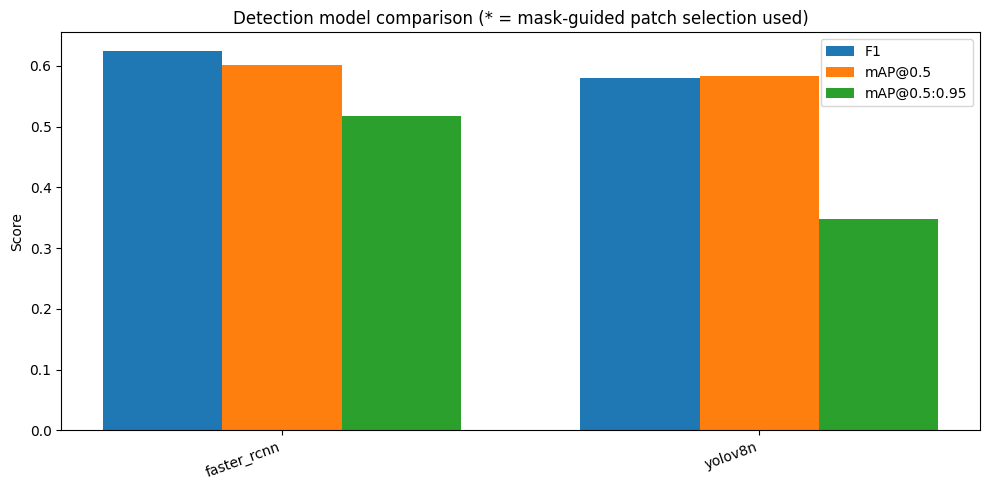


Chart saved to: /content/drive/MyDrive/tiger_dataset/detection_runs/detection_comparison_chart.png


In [47]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(sorted_df))
labels = [f"{row['architecture']}{'*' if row.get('mask_guided', False) else ''}"
          for _, row in sorted_df.iterrows()]

width = 0.25
ax.bar([i - width for i in x], sorted_df['f1'], width, label='F1')
ax.bar(x, sorted_df['map50'], width, label='mAP@0.5')
ax.bar([i + width for i in x], sorted_df['map50_95'], width, label='mAP@0.5:0.95')

ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_title('Detection model comparison (* = mask-guided patch selection used)')
ax.legend()
plt.tight_layout()
plt.savefig(CHART_OUTPUT_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChart saved to: {CHART_OUTPUT_PATH}")


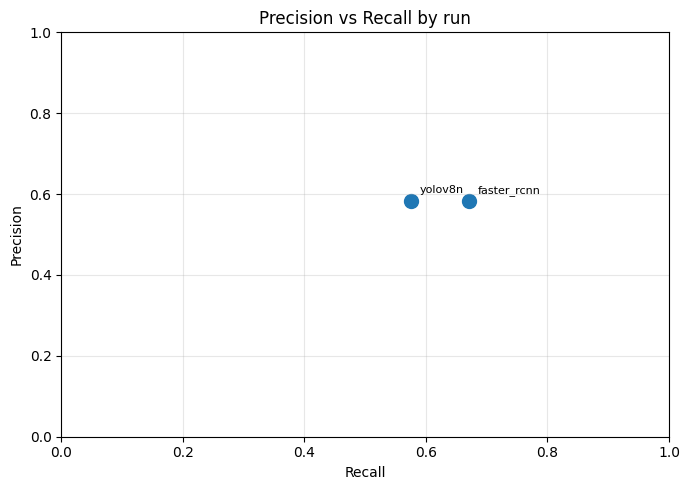

In [48]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sorted_df['recall'], sorted_df['precision'], s=100)
for _, row in sorted_df.iterrows():
    ax.annotate(row['architecture'], (row['recall'], row['precision']),
                textcoords="offset points", xytext=(6, 6), fontsize=8)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision vs Recall by run')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Step 5 — Assemble the standalone Markdown report

Builds a self-contained `.md` file: dataset summary, methodology recap, the results table, and
a reference to the saved chart image — ready to drop into your GitHub repo.


In [49]:
def build_markdown_report():
    lines = []
    lines.append(f"# {PROJECT_TITLE}")
    lines.append("")
    lines.append(f"*Report generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}*")
    lines.append("")
    lines.append("## Dataset Summary")
    lines.append("")
    for k, v in DATASET_SUMMARY.items():
        lines.append(f"- **{k}:** {v}")
    lines.append("")
    lines.append("## Results")
    lines.append("")
    lines.append(f"{len(sorted_df)} model configuration(s) evaluated. Sorted by mAP@0.5:0.95 "
                  f"(the strictest standard detection metric).")
    lines.append("")
    lines.append(sorted_df.to_markdown(index=False))
    lines.append("")
    lines.append(f"**Best configuration:** `{best_run['architecture']}`"
                  + (" (with mask-guided patch selection)" if best_run.get('mask_guided', False) else "")
                  + f" — F1 = {best_run['f1']:.4f}, mAP@0.5 = {best_run['map50']:.4f}, "
                    f"mAP@0.5:0.95 = {best_run['map50_95']:.4f}")
    lines.append("")
    lines.append("## Comparison Chart")
    lines.append("")
    lines.append(f"![Detection model comparison]({os.path.basename(CHART_OUTPUT_PATH)})")
    lines.append("")
    lines.append("## Notes")
    lines.append("")
    lines.append("- `*` in the chart legend indicates mask-guided peritumoral-stroma patch "
                  "selection was used for that run (see `05_Training_Detection.ipynb`, Step 3).")
    lines.append("- Stain normalization (Macenko) was added beyond the official TIGER baseline, "
                  "based on EDA evidence of clear color-distribution differences across the "
                  "RUMC/JB/TCGA sources.")
    return "\n".join(lines)


report_markdown = build_markdown_report()

with open(REPORT_OUTPUT_PATH, 'w') as f:
    f.write(report_markdown)

print(f"Report written to: {REPORT_OUTPUT_PATH}\n")
print("--- Preview ---\n")
print(report_markdown)


Report written to: /content/drive/MyDrive/tiger_dataset/detection_runs/DETECTION_REPORT.md

--- Preview ---

# TIGER Grand Challenge — Detection Track (Lymphocyte/Plasma Cell Detection)

*Report generated: 2026-07-22 10:09*

## Dataset Summary

- **Total ROI images:** 4016
- **Sources:** RUMC, JB, TCGA
- **Preprocessing:** Macenko stain normalization, resize to 512x512, COCO -> YOLO conversion
- **Split:** 70/15/15 train/val/test, stratified by source

## Results

2 model configuration(s) evaluated. Sorted by mAP@0.5:0.95 (the strictest standard detection metric).

| architecture   |   precision |   recall |       f1 |    map50 |   map50_95 | mask_guided   |
|:---------------|------------:|---------:|---------:|---------:|-----------:|:--------------|
| faster_rcnn    |    0.582759 | 0.671134 | 0.623832 | 0.600687 |   0.517564 | False         |
| yolov8n        |    0.582969 | 0.575276 | 0.579097 | 0.582699 |   0.347509 | False         |

**Best configuration:** `faster_rcnn` — F1 = 0.